<a href="https://colab.research.google.com/github/azcsprof/ASU-CSE475-SS25/blob/Unit-3-ICE-2/Unit_3_ICE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive Guide: Multi-Layer Perceptron (MLP) for Learning Y = X²

This notebook builds and trains a simple two-layer perceptron to learn the quadratic function \( Y = X^2 \). You'll also interact with model hyperparameters and see how predictions change based on network settings.


## 🔍 MLP Architecture Visualization

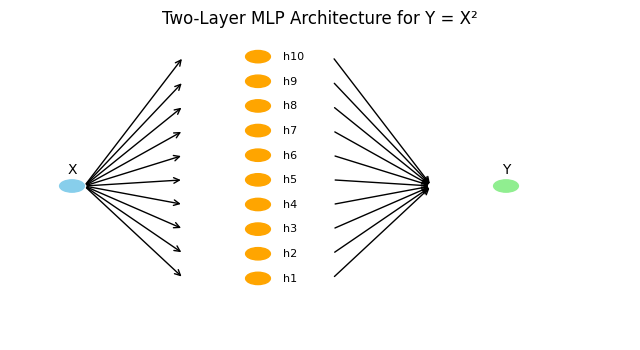

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_mlp_architecture():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.add_patch(mpatches.Circle((0.5, 2), 0.1, fill=True, color='skyblue'))
    ax.text(0.5, 2.2, "X", ha="center")

    for i in range(10):
        ax.add_patch(mpatches.Circle((2, i * 0.4 + 0.5), 0.1, fill=True, color='orange'))
        ax.text(2.2, i * 0.4 + 0.5, f"h{i+1}", va="center", fontsize=8)

    ax.add_patch(mpatches.Circle((4, 2), 0.1, fill=True, color='lightgreen'))
    ax.text(4, 2.2, "Y", ha="center")

    for i in range(10):
        ax.annotate("", xy=(1.4, i * 0.4 + 0.5), xytext=(0.6, 2),
                    arrowprops=dict(arrowstyle="->", lw=1))

    for i in range(10):
        ax.annotate("", xy=(3.4, 2), xytext=(2.6, i * 0.4 + 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1))

    ax.set_xlim(0, 5)
    ax.set_ylim(-0.5, 4.5)
    ax.axis("off")
    plt.title("Two-Layer MLP Architecture for Y = X²")
    plt.show()

draw_mlp_architecture()

## 🎛️ Hyperparameter Tuning Widget

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from ipywidgets import interact, FloatSlider, IntSlider
import matplotlib.pyplot as plt

torch.manual_seed(42)

def train_mlp(learning_rate=0.05, hidden_size=10):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(1, hidden_size)
            self.fc2 = nn.Linear(hidden_size, 1)
        def forward(self, x):
            x = F.relu(self.fc1(x))
            return self.fc2(x)

    model = Net()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    X = 2 * torch.rand(1000, 1) - 1
    Y = X ** 2

    for epoch in range(10):
        total_loss = 0
        for i in range(X.size(0)):
            x = X[i]
            y = Y[i]
            optimizer.zero_grad()
            output = model(x)
            loss = nn.MSELoss()(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    with torch.no_grad():
        x_vals = torch.linspace(-1, 1, 200).unsqueeze(1)
        preds = model(x_vals).numpy()

    plt.figure(figsize=(6, 4))
    plt.plot(x_vals.numpy(), x_vals.numpy() ** 2, label="True Y = X²", linestyle='--')
    plt.plot(x_vals.numpy(), preds, label="Predicted", alpha=0.8)
    plt.title(f"Hidden Size: {hidden_size}, LR: {learning_rate}")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(
    train_mlp,
    learning_rate=FloatSlider(min=0.001, max=0.2, step=0.005, value=0.05),
    hidden_size=IntSlider(min=2, max=50, step=2, value=10)
)

interactive(children=(FloatSlider(value=0.05, description='learning_rate', max=0.2, min=0.001, step=0.005), In…

<function __main__.train_mlp(learning_rate=0.05, hidden_size=10)>

### ✅ You're Ready to Experiment

Use the visualization to understand model architecture. Use the widget to experiment with learning rate and hidden size. Observe how well the network approximates the true function \( Y = X^2 \).
